**DATA ANALYSIS WITH PANDAS**

INSTALL LIBRARIES

In [ ]:
import sys
!{sys.executable} -m pip install --upgrade matplotlib pandas

IMPORT LIBRARIES

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

READ DATA WITH PANDAS

In [4]:
df = pd.read_csv("data\sales.csv", encoding="utf-8", header=0 )
df.info()

<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\Usuario\AppData\Local\Temp\ipykernel_3036\3847603031.py:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  df = pd.read_csv("data\sales.csv", encoding="utf-8", header=0 )


<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   str    
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), str(1)
memory usage: 402.3 KB


PANDAS SETTINGS

In [5]:
df.Date = pd.to_datetime(df.Date, format='%d-%m-%Y') #Make date column to datetime instead of str. Giving the date format of the csv
print (df.Date.dtype)
pd.set_option('display.float_format', lambda x: '{:,.2f}' .format(x))

datetime64[us]


Create Year and Month columns to work with

In [6]:
df['Month'] = df.Date.dt.month
df['Year'] = df.Date.dt.year

df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Year
0,1,2010-02-05,"1,643,690.90",0,42.31,2.57,211.10,8.11,2,2010
1,1,2010-02-12,"1,641,957.44",1,38.51,2.55,211.24,8.11,2,2010
2,1,2010-02-19,"1,611,968.17",0,39.93,2.51,211.29,8.11,2,2010
3,1,2010-02-26,"1,409,727.59",0,46.63,2.56,211.32,8.11,2,2010
4,1,2010-03-05,"1,554,806.68",0,46.50,2.62,211.35,8.11,3,2010


**ANALYSIS**

Monthly Sales

Month
1              0.00
2    190,332,983.04
3    181,919,802.50
4    231,412,368.05
5    186,710,934.34
6    192,246,172.36
7    232,580,125.98
8    187,640,110.89
9    177,267,896.37
10   217,161,824.02
11   202,853,370.14
12   288,760,532.72
Name: Weekly_Sales, dtype: float64


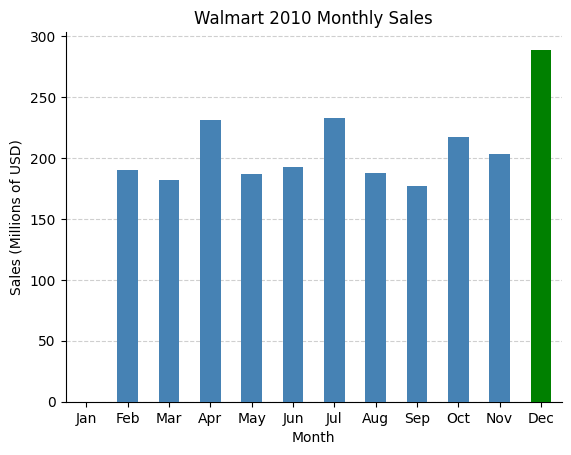

In [12]:
year = 2010  # Change this value to select the year (2010, 2011, 2012)
year_data=df[df['Date'].dt.year == year]  # Filter by year

monthly_sales = year_data.groupby('Month')['Weekly_Sales'].sum()  # group the sales by month and return the total
monthly_sales = monthly_sales.reindex(range(1,13)).fillna(0)

top_month = monthly_sales.max()  
worst_month = monthly_sales.min()
month_names=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

print(monthly_sales)

# Graph
colors = ['green' if v == top_month else 'steelblue' for v in monthly_sales]
(monthly_sales/1000000).plot(kind='bar', title=f'Walmart {year} Monthly Sales', ylabel='Sales (Millions of USD)', color=colors, zorder=4)
plt.xticks(range(12), month_names, rotation=0)  # show month names
plt.grid(axis='y', linestyle='--', alpha=0.6, zorder=1)  # grid settings
plt.gca().spines['top'].set_visible(False) # spines visibility
plt.gca().spines['right'].set_visible(False)

Annual Sales

Year
2010   2,288,886,120.41
2011   2,448,200,007.35
2012   2,000,132,859.35
Name: Weekly_Sales, dtype: float64


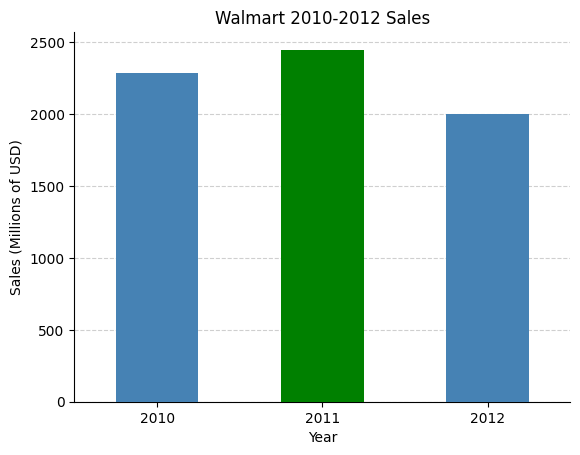

In [ ]:
annual_sales= df.groupby('Year')['Weekly_Sales'].sum()
print(annual_sales)

# Graph
colors = ['green' if v == annual_sales.max() else 'steelblue' for v in annual_sales]
(annual_sales/1000000).plot(kind='bar', title='Walmart 2010-2012 Sales', ylabel='Sales (Millions of USD)', color=colors, zorder=4)
plt.xticks(rotation=0) 
plt.grid(axis='y', linestyle='--', alpha=0.6, zorder=1)  # grid settings
plt.gca().spines['top'].set_visible(False) # spines visibility
plt.gca().spines['right'].set_visible(False)